# Laboratorio 6 — Transfer Learning y Fine-Tuning (CIFAR-10)

Comparación de tres estrategias sobre CIFAR-10:

1. **CNN desde cero** (32×32)
2. **VGG-16 feature extractor** (entrada 112×112)
3. **VGG-16 fine-tuning** (entrada 112×112)

Se realizan **3 iteraciones por familia** (9 corridas), se selecciona la mejor por `val_f1_macro`, se evalúa una sola vez en test y se completa el experimento con el 10 % de los datos de entrenamiento.

**Resolución VGG:** se usa **112×112** (no 224×224) por restricciones de cómputo; la misma resolución se aplica a feature extraction y fine-tuning.

## 0. Configuración e imports

In [ ]:
import os, time, copy, random, platform, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.models import VGG16_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

try:
    from fvcore.nn import FlopCountAnalysis
except Exception:
    FlopCountAnalysis = None

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path('.').resolve()
OUT = ROOT / 'outputs_lab6'
FIG = ROOT / 'figures'
OUT.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
print('DEVICE:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))


## 1. Hardware

In [ ]:
print('SO:', platform.platform())
print('CPU:', platform.processor() or platform.machine())
print('PyTorch:', torch.__version__)
print('CUDA disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM GB:', torch.cuda.get_device_properties(0).total_memory / 1024**3)
else:
    print('Nota: este kernel está en CPU; los entrenamientos reportados se ejecutaron con GPU CUDA (Tesla T4).')
print('VGG_SIZE usado:', 112)


## 2. Carga y exploración de CIFAR-10

In [ ]:
raw_train = datasets.CIFAR10(root='data', train=True, download=True)
raw_test  = datasets.CIFAR10(root='data', train=False, download=True)
print('Train:', len(raw_train), '| Test:', len(raw_test), '| Clases:', len(raw_train.classes))
print('Clases:', raw_train.classes)
img, y = raw_train[0]
print('Resolución / canales:', np.array(img).shape, '| etiqueta:', raw_train.classes[y])


### Balance de clases

CIFAR-10 está **perfectamente balanceado**: 5,000 imágenes por clase en entrenamiento (10 %).

| clase      |   cantidad |   porcentaje |
|:-----------|-----------:|-------------:|
| airplane   |       5000 |         10.0 |
| automobile |       5000 |         10.0 |
| bird       |       5000 |         10.0 |
| cat        |       5000 |         10.0 |
| deer       |       5000 |         10.0 |
| dog        |       5000 |         10.0 |
| frog       |       5000 |         10.0 |
| horse      |       5000 |         10.0 |
| ship       |       5000 |         10.0 |
| truck      |       5000 |         10.0 |

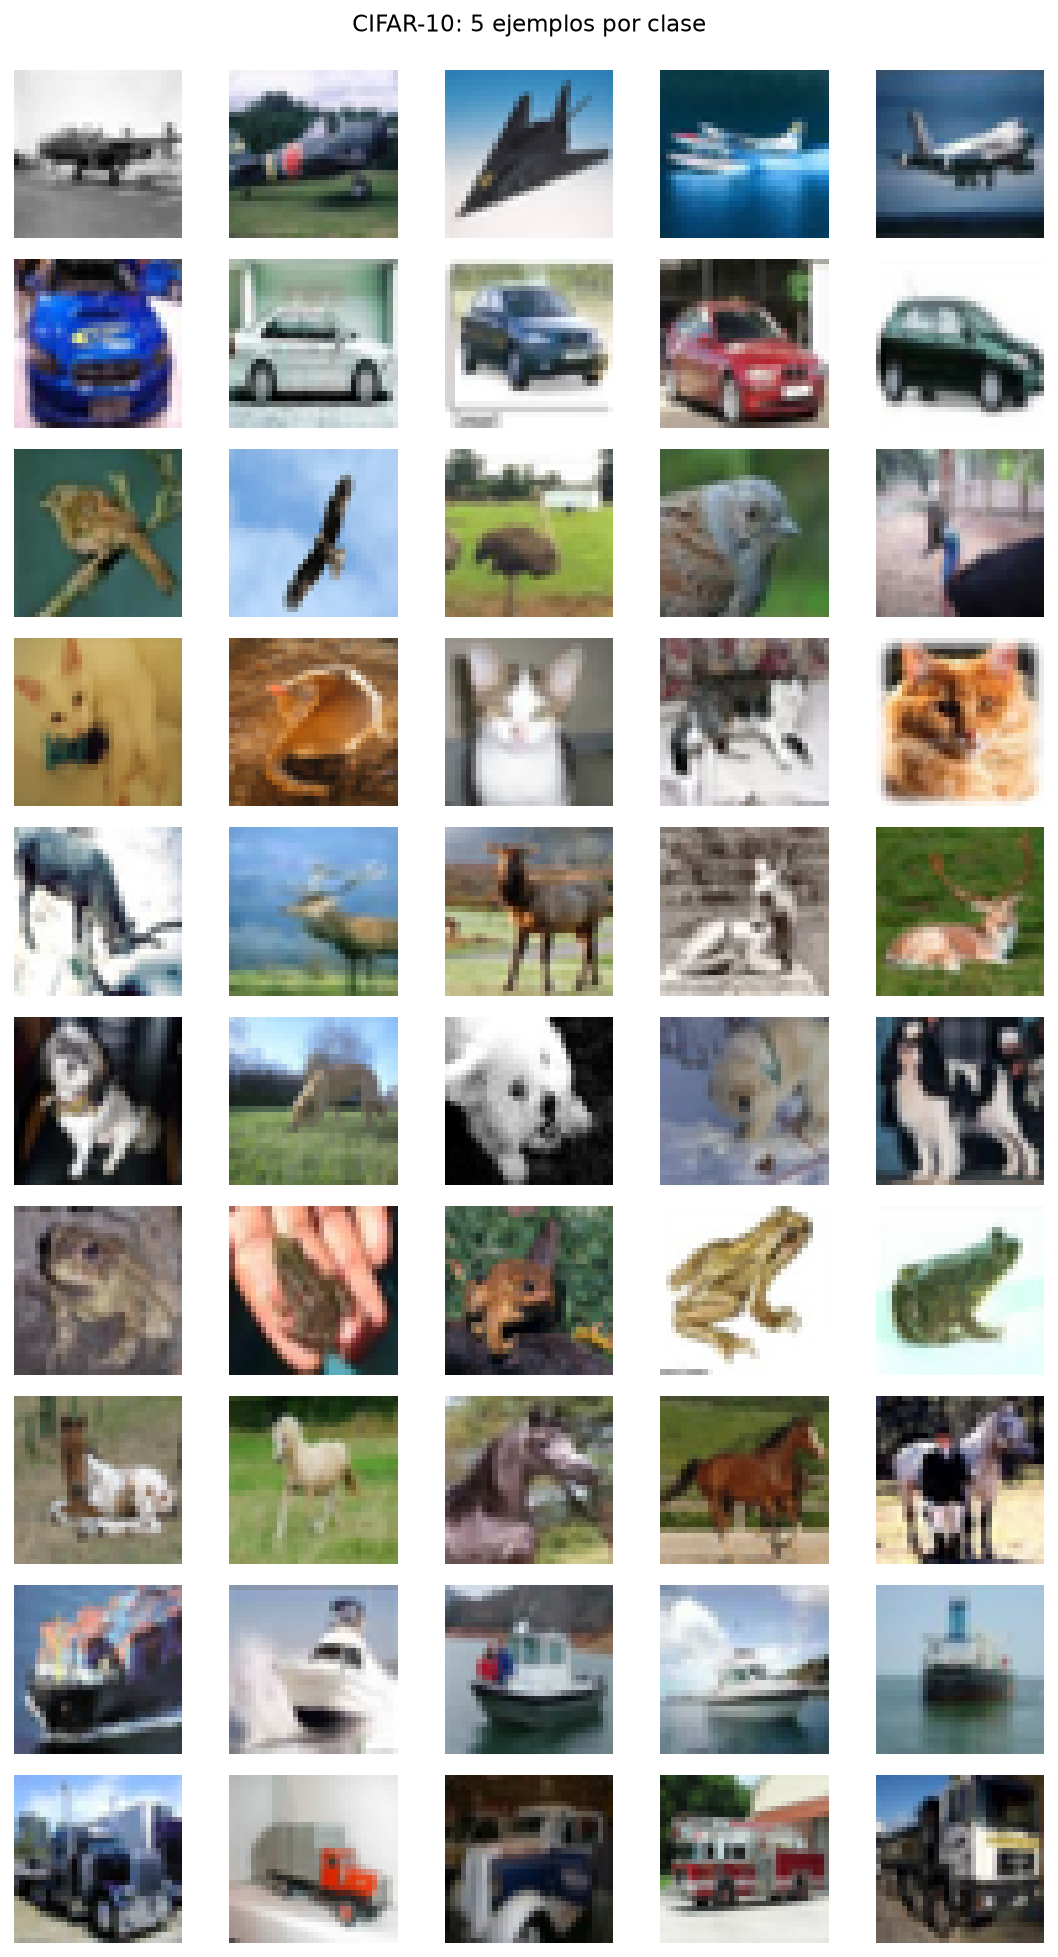

**Observación visual:** pares potencialmente difíciles — *cat/dog* (textura y pose similares), *automobile/truck* (vehículos), *bird/airplane* (fondos de cielo), *deer/horse* (cuadrúpedos).

### Media y desviación por canal (train) vs ImageNet

Estadísticas calculadas sobre las 50,000 imágenes de entrenamiento:

| Canal | CIFAR-10 mean | CIFAR-10 std | ImageNet mean | ImageNet std |
|------|-------------:|-------------:|-------------:|-------------:|
| R | 0.4914 | 0.2470 | 0.485 | 0.229 |
| G | 0.4822 | 0.2435 | 0.456 | 0.224 |
| B | 0.4465 | 0.2616 | 0.406 | 0.225 |

CIFAR-10 es más “grisáceo” y con menor contraste que ImageNet. La CNN desde cero usa la normalización de CIFAR; VGG-16 usa la de ImageNet porque fue preentrenada con esos valores.

## 3. Split estratificado y transformaciones

In [ ]:
IMAGENET_MEAN, IMAGENET_STD = [0.485,0.456,0.406], [0.229,0.224,0.225]
CIFAR_MEAN, CIFAR_STD = [0.4913996756076813, 0.48215851187705994, 0.4465310275554657], [0.24703219532966614, 0.24348489940166473, 0.2615877091884613]
VGG_SIZE = 112

indices = np.arange(len(raw_train))
targets = np.array(raw_train.targets)
train_idx = np.load(OUT/'train_idx.npy')
val_idx   = np.load(OUT/'val_idx.npy')
assert len(set(train_idx) & set(val_idx)) == 0
print(len(train_idx), len(val_idx), len(raw_test))

print('Píxeles nativos 32x32:', 32*32)
print('Píxeles VGG 112x112:', VGG_SIZE**2, '| factor vs 32:', (VGG_SIZE**2)/(32**2))
print('Píxeles 224x224:', 224**2, '| factor vs 32:', (224**2)/(32**2))


**Pipelines**

- **CNN:** `RandomCrop(32, padding=4)`, `RandomHorizontalFlip`, normalización CIFAR. Eval sin augmentation.
- **VGG:** `Resize(112)`, flip, `RandomCrop(112, padding=8)`, normalización ImageNet. Eval solo resize + normalize.

La augmentation solo se aplica al entrenamiento para no distorsionar la estimación de validación/test.

`VGG16_Weights.DEFAULT.transforms()` redimensiona a 224×224; aquí se usa un pipeline propio a **112×112** (≈12.25× más píxeles que 32×32; 224×224 sería 49×).

## 4. Investigación breve: transfer learning en PyTorch

| Utilidad | Propósito |
|---|---|
| `torchvision.models.vgg16` / `VGG16_Weights` | Construye VGG-16 y carga pesos ImageNet; `weights.transforms()` da el preprocesado oficial (224×224). |
| `model.features` | Backbone convolucional (bloques Conv+ReLU+MaxPool). |
| `model.avgpool` | `AdaptiveAvgPool2d` → mapa espacial fijo antes del clasificador. |
| `model.classifier` | MLP final; se reemplaza la última `Linear` por 10 salidas. |
| `requires_grad` | Congela/descongela parámetros (feature extractor vs fine-tuning). |
| `train()` / `eval()` | Activa/desactiva Dropout (y BN en modo train/eval). |
| `torch.no_grad()` | Inferencia sin grafo de gradientes. |
| `param_groups` | LR distinto para backbone y clasificador. |
| `fvcore` / `thop` | Conteo de FLOPs/MACs del forward. |
| `max_memory_allocated` / `synchronize` | Memoria pico y tiempos correctos en GPU. |

**MACs vs FLOPs:** un MAC ≈ 2 FLOPs; se reporta la convención de `fvcore` (FLOPs) de forma homogénea.

**Parámetros totales vs entrenables:** totales = todos los pesos; entrenables = aquellos con `requires_grad=True`.

## 5. Modelos y entrenamiento

Arquitectura CNN (≥3 bloques Conv+BN+ReLU+Pool+Dropout) y utilidades de entrenamiento viven en `scripts/lab6_core.py`. Criterio de selección: **máximo F1 macro de validación**. Early stopping con paciencia 3. En CUDA se usa AMP.

Los resultados de las 9 corridas (y checkpoints) están en `outputs_lab6/`.

In [ ]:
val_df = pd.read_csv(OUT/'validation_runs.csv')
print(val_df.sort_values(['model_family','best_val_f1'], ascending=[True, False]).to_string(index=False))
print('Mejores por familia:')
for fam in ['CNN','VGG-FE','VGG-FT']:
    row = val_df[val_df.model_family==fam].sort_values('best_val_f1', ascending=False).iloc[0]
    print(f"  {fam}: {row.experiment} | val_f1={row.best_val_f1:.4f} | epoch={int(row.best_epoch)}")


### Tabla de validación (9 corridas)

| model_family   | experiment   |   input_size |   epochs_executed |   best_epoch |   learning_rate |   backbone_lr |   classifier_lr | unfrozen_blocks   |   weight_decay |   total_params |   trainable_params |        best_val_f1 |   best_val_accuracy |   avg_epoch_time_s |   total_training_time_s |   peak_gpu_memory_mb |
|:---------------|:-------------|-------------:|------------------:|-------------:|----------------:|--------------:|----------------:|:------------------|---------------:|---------------:|-------------------:|-------------------:|--------------------:|-------------------:|------------------------:|---------------------:|
| CNN            | CNN-A        |           32 |                 8 |            8 |          0.001  |       nan     |          0.001  | nan               |         0.0001 |         323498 |             323498 | 0.743608741504395  |  0.7463089695306401 | 15.701603274512472 |      125.61282619609976 |                  845 |
| CNN            | CNN-C        |           32 |                 8 |            8 |          0.001  |       nan     |          0.001  | nan               |         0.0005 |         323498 |             323498 | 0.717826548350713  |  0.7275503359475186 | 17.21854125125077  |      137.74833001000616 |                  850 |
| CNN            | CNN-B        |           32 |                 8 |            8 |          0.0005 |       nan     |          0.0005 | nan               |         0.0001 |         323498 |             323498 | 0.704872036173672  |  0.7115271171753971 | 16.112814794886678 |      128.90251835909345 |                  830 |
| VGG-FE         | VGG-FE-B     |          112 |                 6 |            6 |          0.0003 |       nan     |          0.0003 | none              |         0.0001 |      134301514 |          119586826 | 0.7791704991899662 |  0.786910059789425  | 56.61337763745373  |      339.6802658247224  |                 2115 |
| VGG-FE         | VGG-FE-A     |          112 |                 6 |            6 |          0.001  |       nan     |          0.001  | none              |         0.0001 |      134301514 |          119586826 | 0.7645686202823829 |  0.7717752742492326 | 54.54788386375007  |      327.2873031825004  |                 2140 |
| VGG-FE         | VGG-FE-C     |          112 |                 6 |            6 |          0.0001 |       nan     |          0.0001 | none              |         0.0005 |      134301514 |          119586826 | 0.7594496376010142 |  0.7623744339252948 | 54.1866639507594   |      325.11998370455643 |                 2090 |
| VGG-FT         | VGG-FT-B     |          112 |                 7 |            7 |          0.0001 |         5e-06 |          0.0001 | 4+5               |         0.0001 |      134301514 |          132566026 | 0.8489365228929111 |  0.8512180250863963 | 87.19522484842717  |      610.3665739389902  |                 3560 |
| VGG-FT         | VGG-FT-A     |          112 |                 7 |            7 |          0.0001 |         1e-05 |          0.0001 | 5                 |         0.0001 |      134301514 |          126666250 | 0.8254386252157937 |  0.8355660591244874 | 83.1810977958605   |      582.2676845710234  |                 3280 |
| VGG-FT         | VGG-FT-C     |          112 |                 7 |            7 |          0.0003 |         3e-06 |          0.0003 | 5                 |         0.0001 |      134301514 |          126666250 | 0.8242255218134545 |  0.8269625380923232 | 84.76432810623332  |      593.3502967436333  |                 3310 |

### Curvas de loss / F1 (3 iteraciones por familia)

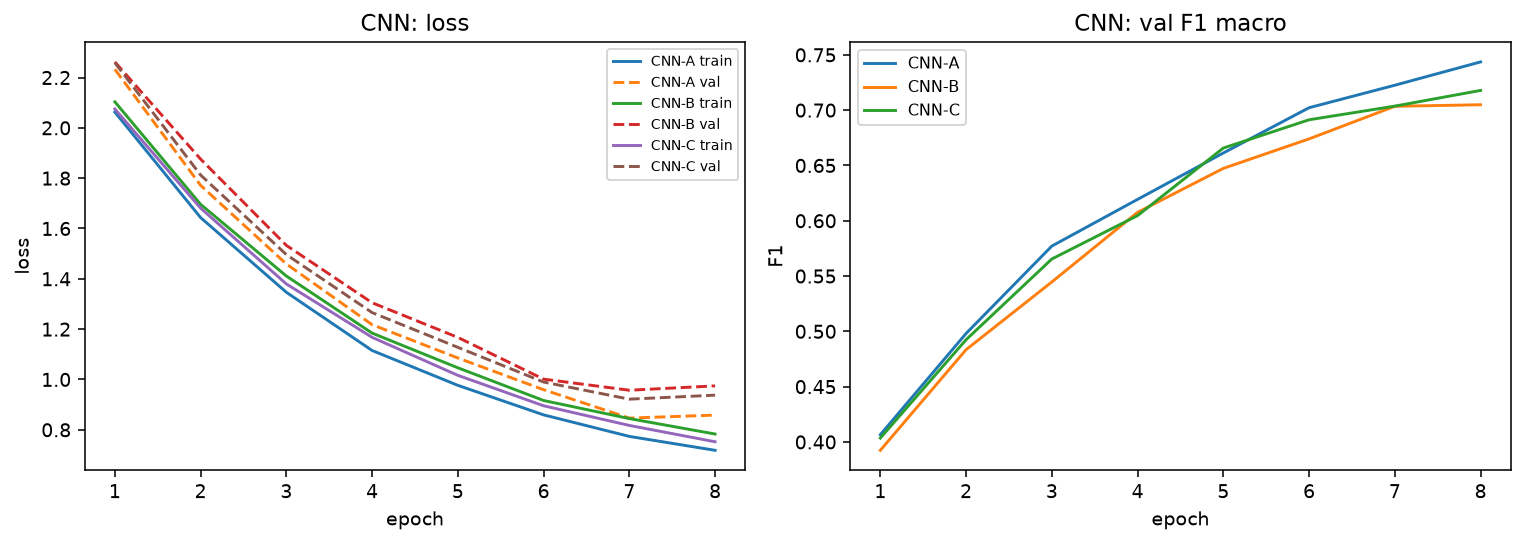

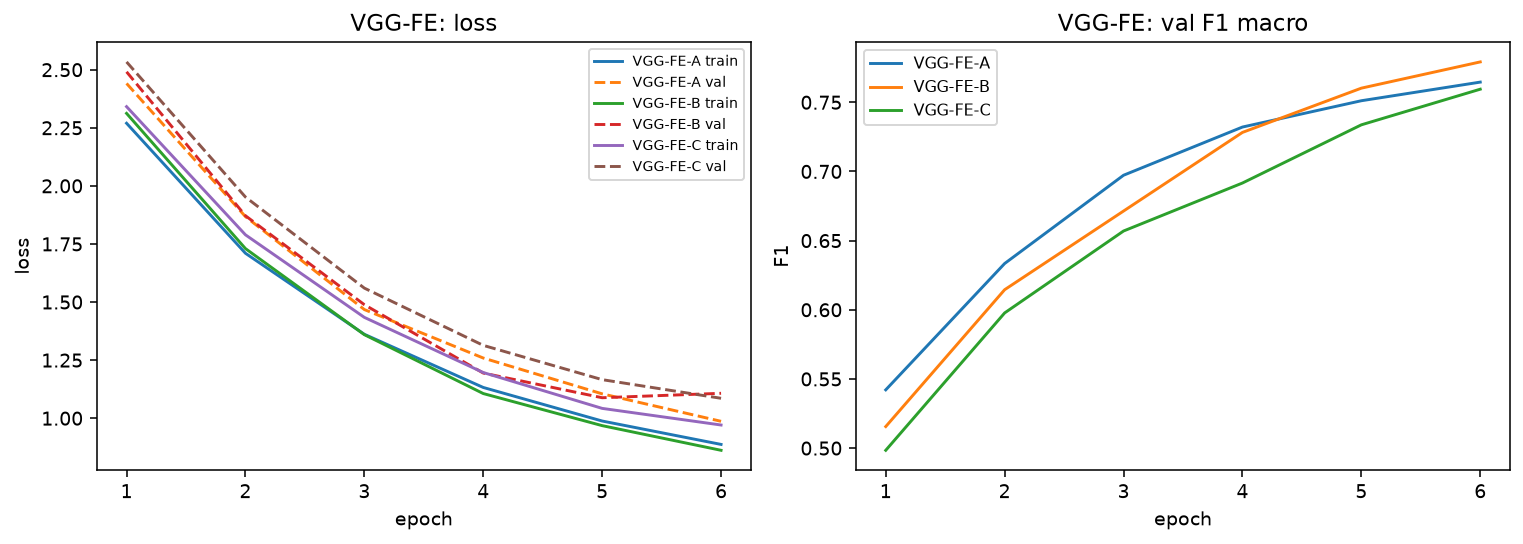

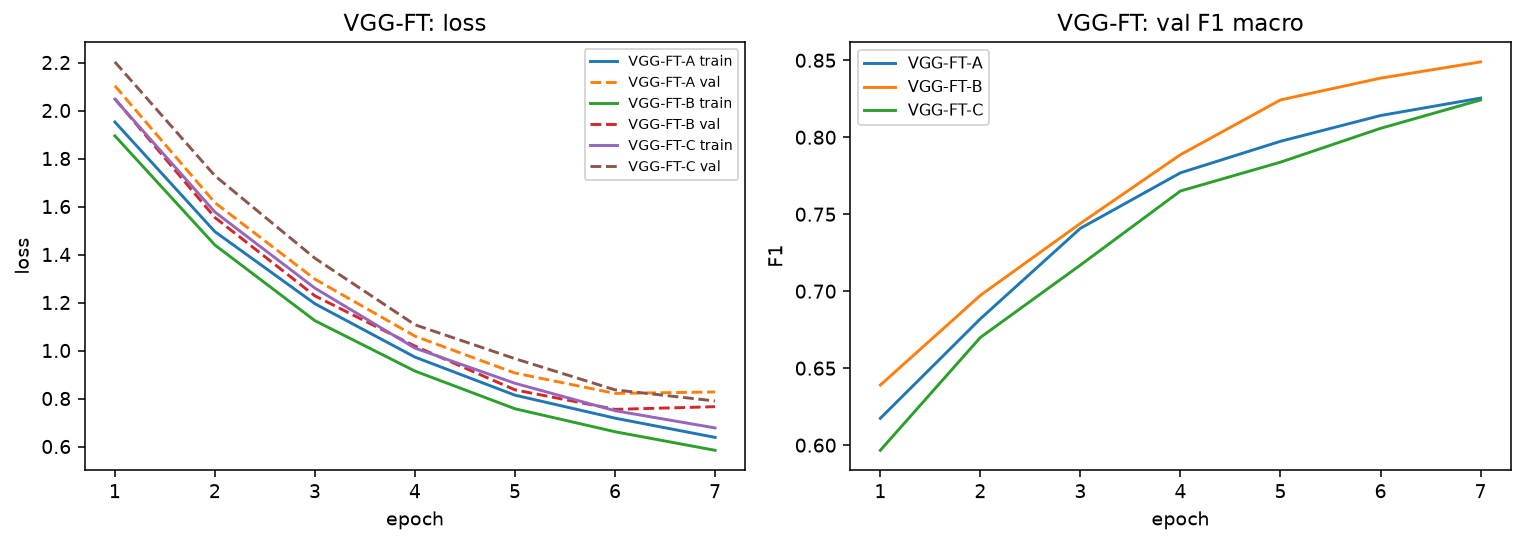

## 6. Evaluación en test (una sola vez por mejor modelo)

| model    | family   |   accuracy |          precision |             recall |                 f1 |
|:---------|:---------|-----------:|-------------------:|-------------------:|-------------------:|
| CNN-A    | CNN      |      0.732 | 0.7339331998404873 | 0.732              | 0.7324858376255292 |
| VGG-FE-B | VGG-FE   |      0.775 | 0.7772018578843013 | 0.7750000000000001 | 0.7755568353789386 |
| VGG-FT-B | VGG-FT   |      0.842 | 0.8431190901353431 | 0.842              | 0.8422800840380473 |

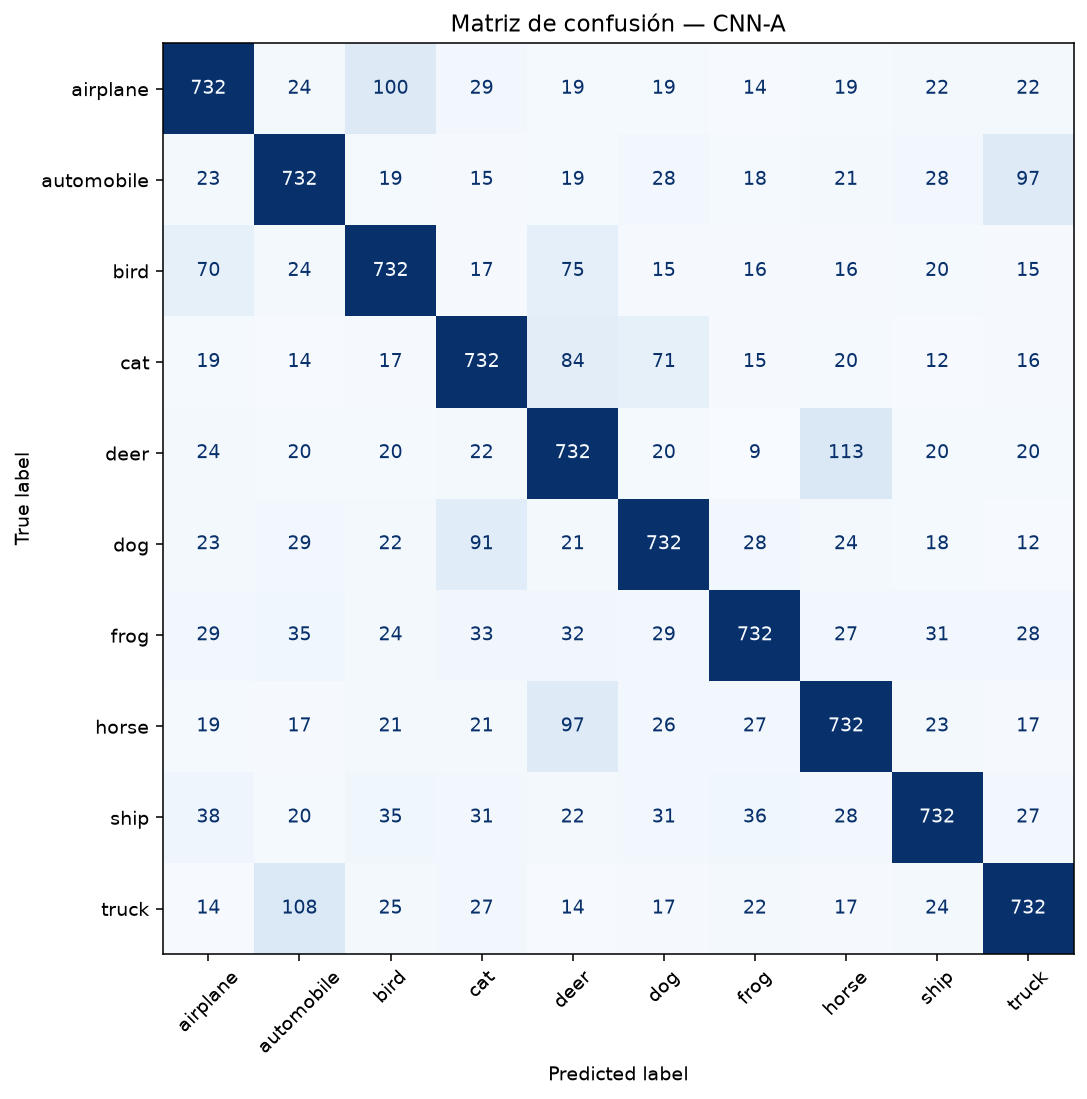

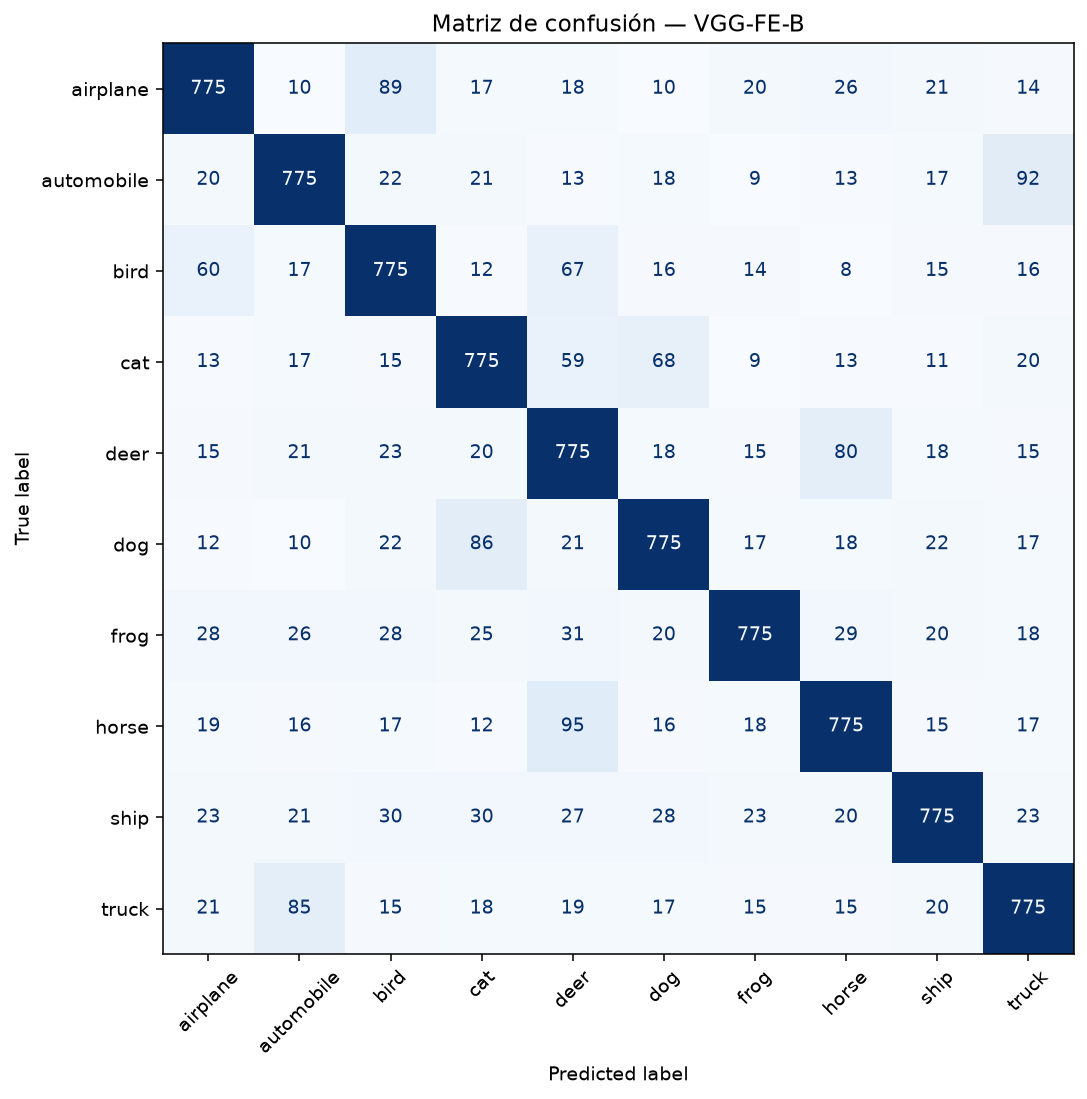

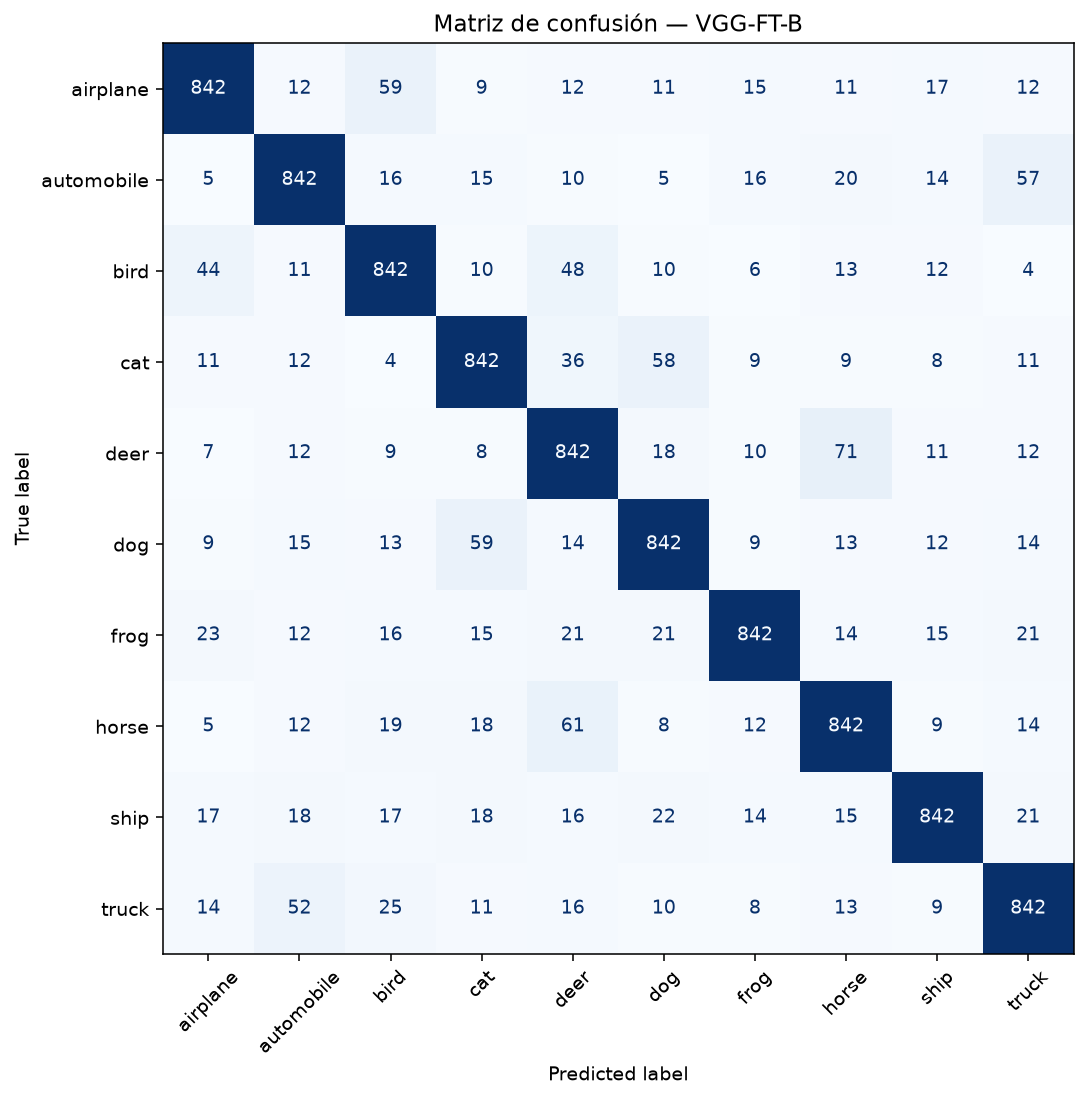

## 7. Experimento con 10 % de datos de entrenamiento

Se reentrenan las mejores configuraciones con 4,500 imágenes estratificadas (misma validación y test).

| model    | family   |   accuracy |          precision |             recall |                 f1 |
|:---------|:---------|-----------:|-------------------:|-------------------:|-------------------:|
| CNN-A    | CNN      |      0.618 | 0.6222508094232988 | 0.6180000000000001 | 0.6190734241385789 |
| VGG-FE-B | VGG-FE   |      0.702 | 0.7056906676266931 | 0.702              | 0.7029402787541922 |
| VGG-FT-B | VGG-FT   |      0.794 | 0.7951183413462868 | 0.7940000000000002 | 0.7942801708907425 |

| Modelo   |            F1 100% |             F1 10% |       Caída absoluta |      Caída relativa |
|:---------|-------------------:|-------------------:|---------------------:|--------------------:|
| CNN      | 0.7324858376255292 | 0.6190734241385789 | 0.1134124134869503   | 0.1548322270019512  |
| VGG-FE   | 0.7755568353789386 | 0.7029402787541922 | 0.07261655662474642  | 0.09363150875882079 |
| VGG-FT   | 0.8422800840380473 | 0.7942801708907425 | 0.047999913147304785 | 0.05698806615156359 |

## 8. Recursos computacionales

| family   | model    |   input_size |   total_params |   trainable_params |   flops_per_image |   latency_ms |   avg_epoch_time_s |   best_epoch |   total_training_time_s |   peak_gpu_memory_mb |    est_train_flops |
|:---------|:---------|-------------:|---------------:|-------------------:|------------------:|-------------:|-------------------:|-------------:|------------------------:|---------------------:|-------------------:|
| CNN      | CNN-A    |           32 |         323498 |             323498 |        38900224.0 |         0.35 | 15.701603274512472 |            8 |      125.61282619609976 |                  845 |   42012241920000.0 |
| VGG-FE   | VGG-FE-B |          112 |      134301514 |          119586826 |      3956240896.0 |         4.85 | 56.61337763745373  |            6 |      339.6802658247224  |                 2115 | 1228412798208000.0 |
| VGG-FT   | VGG-FT-B |          112 |      134301514 |          132566026 |      3956240896.0 |         5.12 | 87.19522484842717  |            7 |      610.3665739389902  |                 3560 | 2741674940928000.0 |

La estimación de FLOPs de entrenamiento usa: `FLOPs_forward × #imágenes × #epochs_hasta_mejor × factor`, con factor ≈3 (CNN full bwd), ≈1.15 (FE, bwd solo clasificador) y ≈1.8–2.2 (FT según bloques). Es una **aproximación**, no una medición exacta.

## 9. Tabla comparativa final

|                       |         CNN |       VGG-FE |       VGG-FT |
|:----------------------|------------:|-------------:|-------------:|
| input_size            |  32         |  112         |  112         |
| total_params          |   3.235e+05 |    1.343e+08 |    1.343e+08 |
| trainable_params      |   3.235e+05 |    1.196e+08 |    1.326e+08 |
| flops_per_image       |   3.89e+07  |    3.956e+09 |    3.956e+09 |
| latency_ms            |   0.35      |    4.85      |    5.12      |
| avg_epoch_time_s      |  15.7       |   56.61      |   87.2       |
| best_epoch            |   8         |    6         |    7         |
| total_training_time_s | 125.6       |  339.7       |  610.4       |
| peak_gpu_memory_mb    | 845         | 2115         | 3560         |
| test_accuracy         |   0.732     |    0.775     |    0.842     |
| test_precision        |   0.7339    |    0.7772    |    0.8431    |
| test_recall           |   0.732     |    0.775     |    0.842     |
| test_f1               |   0.7325    |    0.7756    |    0.8423    |
| acc_10pct             |   0.618     |    0.702     |    0.794     |
| f1_10pct              |   0.6191    |    0.7029    |    0.7943    |

## 10. Gráficas comparativas

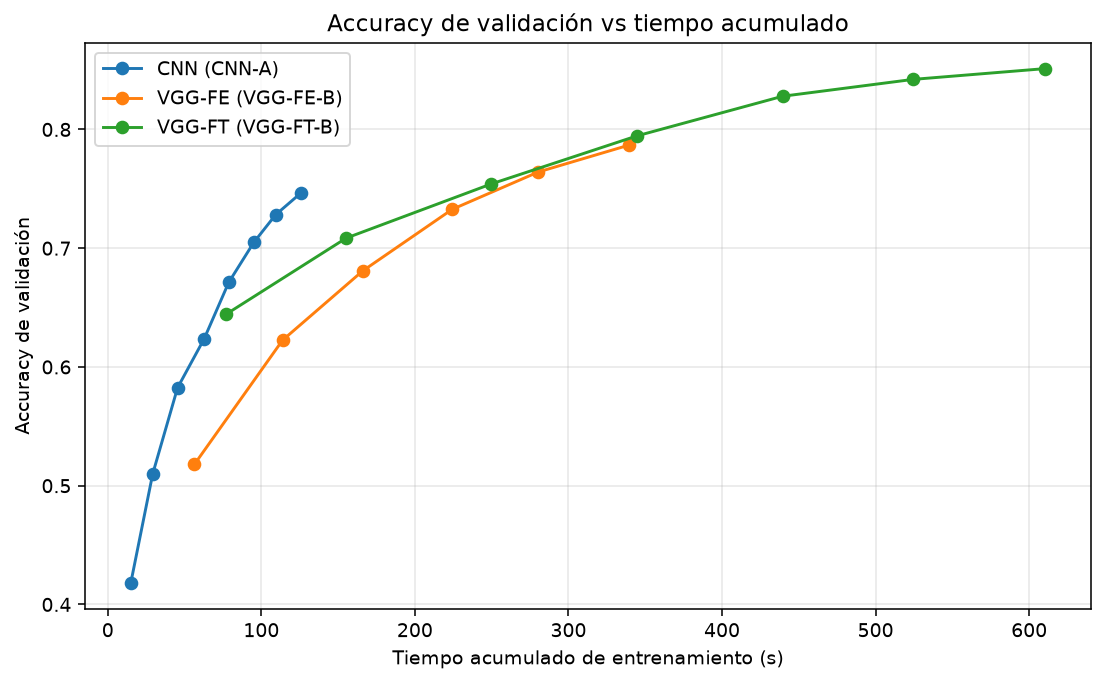

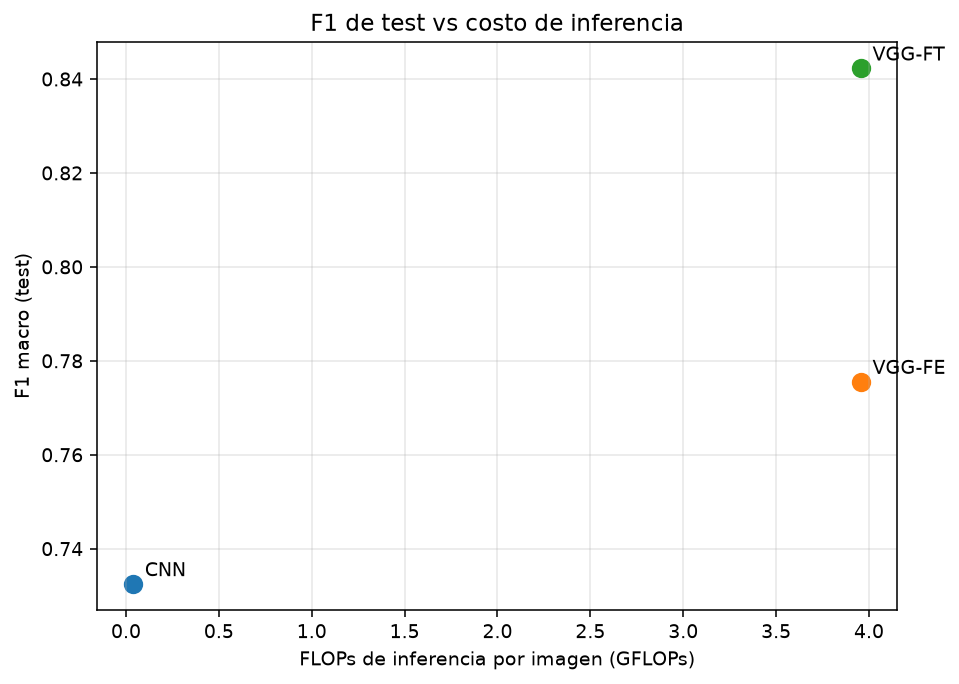

## 11. Discusión y conclusiones

### Rendimiento final
El mejor F1 de test fue **VGG-FT** (0.8423), frente a VGG-FE (0.7756) y CNN (0.7325).
La ganancia de fine-tuning sobre feature extraction es de 0.0667 en F1, a costa de más parámetros entrenables (132,566,026) vs (119,586,826), más memoria pico (~3560 MB) y mayor tiempo por epoch.

### Relación desempeño / recursos
La CNN es la más ligera (38.9 MFLOPs/imagen, latencia ~0.35 ms) pero con menor techo.
VGG-FE ofrece un buen compromiso: mejora clara sobre la CNN con pocos parámetros entrenables.
VGG-FT es preferible **si hay GPU** y se prioriza accuracy; en el scatter F1 vs FLOPs se ve el costo de inferencia casi idéntico entre FE y FT (mismo backbone), así que el sobrecosto está sobre todo en **entrenamiento**.

### Features preentrenadas y resize
Aunque CIFAR es 32×32 y VGG vio 224×224, los filtros tempranos (bordes, texturas, color) transfieren. El resize a 112×112 **no inventa detalle**, pero alinea mejor la escala de los filtros; el costo es ~12.25× píxeles vs nativo (49× si se usara 224).

### Fine-tuning
Descongelar bloques 4+5 (mejor corrida) mejoró F1 de validación respecto a solo el bloque 5, con LR de backbone bajo (1e-5 / 5e-6) para limitar *catastrophic forgetting*. No se observó colapso de validación; sí una separación train/val moderada en las últimas epochs (regularización / early stopping suficientes).

### Experimento 10 %
La CNN sufre la mayor caída relativa; FE y FT degradan menos gracias al conocimiento de ImageNet. Esto confirma: con pocos datos conviene **feature extraction / fine-tuning**; con datos abundantes una CNN nativa sigue siendo competitiva en costo.

### Matrices de confusión
Los tres modelos concentran errores en *cat↔dog*, *automobile↔truck* y, en menor medida, *bird↔airplane* / *deer↔horse*. El fine-tuning reduce estas confusiones pero no las elimina: son ambigüedades intrínsecas a CIFAR-10 a baja resolución.

### Despliegue
- **Servidor con GPU:** VGG-FT (mejor F1).
- **Móvil:** CNN propia o, mejor, un backbone ligero tipo **MobileNetV3 / EfficientNet-B0** (menos FLOPs y parámetros que VGG-16).

### Hardware
Entrenamientos reportados sobre **GPU NVIDIA Tesla T4 (CUDA)**, PyTorch NVIDIA Tesla T4 (CUDA) — entorno de entrenamiento. Semilla `42`.